In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("../data/processed/Merged_dataset.csv")

In [3]:
df.head(1)

,customer_id,customer_unique_id,customer_state,customer_city,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,product_category_name,product_weight_g,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,SP,franca,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57.000000,2017-05-25 10:35:35.000000000,...,credit_card,2,146.87,88b8b52d46df026a9d1ad2136a59b30b,4,2017-05-26 00:00:00,moveis_escritorio,8683.0,itaquaquecetuba,SP


In [4]:
# Frequency of purchase
purchase_counts = (
    df
    .groupby("customer_unique_id")["order_id"]
    .nunique()     
    .reset_index(name="total_purchases")
)

purchase_counts["total_purchases"].value_counts().reset_index()

,total_purchases,count
0,1,90607
1,2,2582
2,3,179
3,4,30
4,5,9
5,6,3
6,7,3
7,9,1
8,15,1


In [5]:
# NUmber of customers having purchase more than once
(purchase_counts[purchase_counts['total_purchases']>1]).shape

(2808, 2)

In [6]:
# Convert the timestamp column to datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Now calculate reference date and perform RFM analysis (taking last date in dataset as reference date)
reference_date = df["order_purchase_timestamp"].max()

# RFM analysis requires.
    # Recency → how recently a customer purchased
    # Frequency → how often a customer purchased
    # Monetary → how much money they spent

rfm = (
    df
    .groupby("customer_unique_id")
    .agg(
        recency_days=(
            "order_purchase_timestamp",
            lambda x: (reference_date - x.max()).days
        ),
        frequency=("order_id", "nunique"),
        monetary=("price", "sum")
    )
    .reset_index()
)

rfm.head()

rfm = (
    df
    .groupby("customer_unique_id")
    .agg(
        recency_days=( #Measures how many days since the last purchase
            "order_purchase_timestamp",
            lambda x: (reference_date - x.max()).days #Converts timedelta to integer days
        ),
        frequency=("order_id", "nunique"),
        monetary=("price", "sum") #Total money spent
    )
    .reset_index()
)

rfm.head()

,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
2,0000f46a3911fa3c0805444483337064,541,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00


## EDA on RFM data

### 1. Monetary values

<Axes: xlabel='monetary', ylabel='Count'>

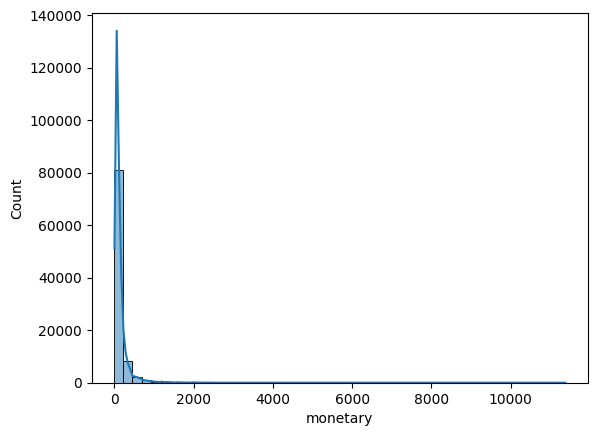

In [7]:
sns.histplot(data=rfm, x='monetary',bins=50, kde=True)

In [8]:
# Handle skewed monetary values (right skewness)
rfm = rfm[rfm['monetary'] > 0]
Monetary_boxcox, lambda_val = boxcox(rfm['monetary'])
print("Best lambda:", lambda_val)

Best lambda: -0.0880334038075619


In [9]:
# As λ < 0 → strong skew → using yeo-johnson
pt = PowerTransformer(method='yeo-johnson')
rfm['Monetary_transformed'] = pt.fit_transform(rfm[['monetary']])

<Axes: xlabel='Monetary_transformed', ylabel='Count'>

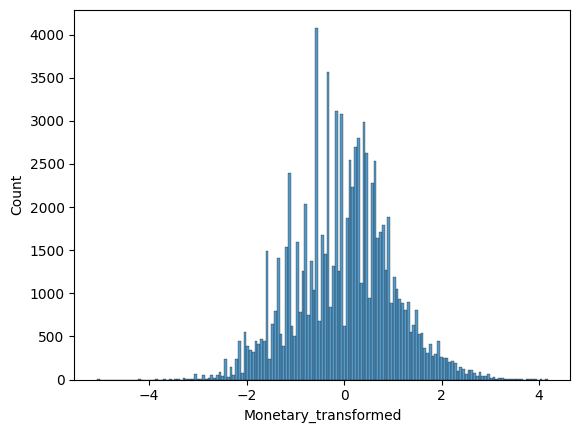

In [10]:
sns.histplot(data=rfm, x='Monetary_transformed')

### 2. Recency Days

<Axes: xlabel='recency_days', ylabel='Count'>

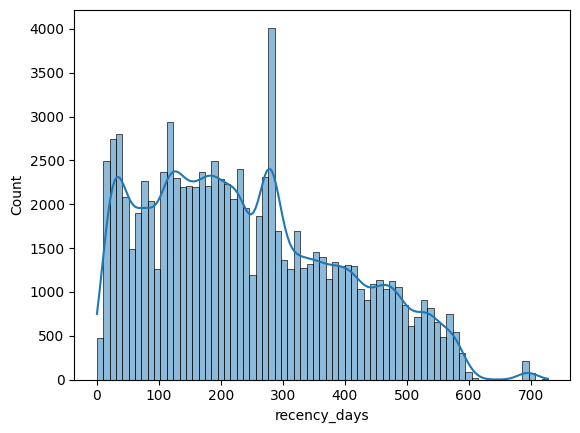

In [11]:
sns.histplot(data=rfm, x='recency_days', kde=True)

In [12]:
# As the dataset does not looks highly skewed and look similar to normal distribution so keep this data as it is.

### 3. Frequency

In [13]:
rfm['frequency'].value_counts()

frequency
1     90607
2      2582
3       179
4        30
5         9
6         3
7         3
9         1
15        1
Name: count, dtype: int64

In [14]:
# Here frequency column is highly skewed so it is very difficult to remove skewness 
# take only 2 frequency values 1 if frequency is 1 and 2 for all frequency greater than 1
rfm['frequency'] = (rfm['frequency'] > 1).astype(int) + 1

In [15]:
px.scatter_3d(data_frame=rfm,x='recency_days',y='frequency',z='Monetary_transformed')

## Scale features

In [16]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["recency_days", "frequency", "Monetary_transformed"]]
)


## Clustering

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

In [18]:
px.scatter_3d(data_frame=rfm,x='recency_days',y='frequency',z='Monetary_transformed',color=rfm['cluster'])

In [19]:
cluster_summary = (
    rfm
    .groupby("cluster")
    .agg(
        avg_recency=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        customer_count=("customer_unique_id", "count")
    )
    .sort_values("avg_monetary", ascending=False)
)
cluster_summary

,avg_recency,avg_frequency,avg_monetary,customer_count
cluster,,,,
3,224.700855,2.0,269.436150,2808
0,159.946009,1.0,231.191858,34561
1,433.287947,1.0,118.962213,26682
2,165.510183,1.0,39.542769,29364


In [20]:
cluster_labels = {
    2: "High Value",
    0: "High Potential",
    3: "At Risk",
    1: "Low Value"
}
rfm["segment"] = rfm["cluster"].map(cluster_labels)

In [21]:
rfm.to_csv("../data/processed/Cust_Segmentation.csv" , index=False) 

In [22]:
rfm.head()

,customer_unique_id,recency_days,frequency,monetary,Monetary_transformed,cluster,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,0.489399,0,High Potential
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,-1.667659,2,High Value
2,0000f46a3911fa3c0805444483337064,541,1,69.00,-0.180624,1,Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,-1.289150,2,High Value
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00,0.819376,0,High Potential


In [23]:
df=df.merge(
    rfm[['customer_unique_id','recency_days','frequency','segment']], 
    on='customer_unique_id', 
    how='inner'
)
df.to_excel('Merged_dataset.xlsx', index=False)

In [24]:
# Cluster 0
#     Purchased recently
#     Only one purchase so far
#     High spend per order
#     Very large group
# Business meaning
#     New or one-time high spenders
#     Potential to become loyal
# Business action
#     Onboarding emails
#     First repeat purchase discounts
#     Product recommendations

# Cluster 1
# Interpretation
#     Purchased relatively recently
#     Single purchase
#     Very low spend
#     Largest cluster
# Business meaning
#     Low value customers
#     Price-sensitive buyers
# Business action
#     Low-cost marketing
#     Bundling offers
#     Do not overspend on retention

# Cluster 2:
# Customers purchased relatively recently compared to others
#     They buy more than once on average
#     Highest spending among all clusters
#     Small but valuable group
# Business meaning
#     Loyal customers
#     Repeat buyers
#     High lifetime value


# Cluster 3
# Interpretation
#     Long time since last purchase
#     Bought only once
#     Medium-low spending
# Business meaning
#     Inactive customers
#     Risk of churn
# Business action
#     Re-engagement campaigns
#     Win-back offers
#     Reminder emails



In [25]:
rfm.head()

,customer_unique_id,recency_days,frequency,monetary,Monetary_transformed,cluster,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,0.489399,0,High Potential
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,-1.667659,2,High Value
2,0000f46a3911fa3c0805444483337064,541,1,69.00,-0.180624,1,Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,-1.289150,2,High Value
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00,0.819376,0,High Potential
